![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# 01 | Exploratory Data Analysis

*Project 1 — SQL: From Data to Insight*

**Team:**
**Dataset:**

---

Understanding your data before you design anything. You cannot decide which tables you need until you know which columns repeat, which are broken, and which identify a row.

> **Done when:** you can name the 3+ tables you are going to build, you have written down at least 2 research questions, and you know every data-quality problem notebook 02 will have to fix.

The sections below are a suggested route, not a form to fill in. Add sections, drop them, reorder them — what is graded is the analysis, not whether you kept the scaffold.

---
## 0. Setup

In [1]:
import sys
sys.path.append("..")          # so `src` is importable from inside notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.functions import *

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

---
## 1. Load the raw data

Run `python download_data.py <payments|airbnb|retail>` from the repo root first. Your files land in `data/raw/`, which is gitignored.

In [2]:
listings = pd.read_csv("../data/raw/listings.csv.gz")
reviews = pd.read_csv("../data/raw/reviews.csv.gz")

print(f"listings: {listings.shape[0]:,} rows × {listings.shape[1]} columns")
print(f"reviews:  {reviews.shape[0]:,} rows × {reviews.shape[1]} columns")

listings: 15,293 rows × 90 columns
reviews:  1,033,523 rows × 6 columns


---
## 2. First look

Shape, column types, a handful of rows. What is one row of this data?

In [3]:
listings.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,18674,https://www.airbnb.com/rooms/18674,20260624162917,2026-06-25,city scrape,Huge flat for 8 people close to Sagrada Familia,110m2 apartment to rent in Barcelona. Located ...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,71615,https://www.airbnb.com/users/show/71615,1.462508e+18,https://www.airbnb.com/users/profile/146250835...,Maria Y Mireia Barcelona4Seasons,NaN,16.0,5.0,15.0,5.0,"Barcelona, Spain","We are Mireia and Maria, two multilingual entr...",NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/pictures/user/User/...,NaN,31.0,NaN,NaN,t,t,NaN,la Sagrada Família,Eixample,41.405560,2.17262,Entire rental unit,Entire home/apt,8,2.0,2 baths,3.0,5.0,"[""AC - split type ductless system"", ""Private p...",$409.00,2026-06-28,2026-06-29,409.00,409.00,"{""quote"": {""taxes"": null, ""currency"": ""EUR"", ""...",1.0,999.0,1.0,4.0,999.0,999.0,2.2,999.0,NaN,t,15,22,52,123,2026-06-25,59,9,1,121,9,54,22086.0,2013-05-27,2026-05-28,4.41,4.47,4.59,4.66,4.64,4.83,4.38,Spain - National registration number<br />ESFC...,NaN,20,20,0,0,0.37
1,23197,https://www.airbnb.com/rooms/23197,20260624162917,2026-06-25,city scrape,CCIB Forum· Large Balcony · 5 min walk to CCIB,"Beautiful, spacious apartment with large balco...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,90417,https://www.airbnb.com/users/show/90417,1.462509e+18,https://www.airbnb.com/users/profile/146250935...,Marnie,NaN,16.0,3.0,15.0,5.0,"Catalonia, Spain","Hi there,\n\nI’m marnie, originally from Austr...",NaN,NaN,NaN,t,NaN,https://a0.muscache.com/im/pictures/user/44b56...,NaN,5.0,NaN,NaN,t,t,NaN,el Besòs i el Maresme,Sant Martí,41.412432,2.21975,Entire rental unit,Entire home/apt,5,2.0,2 baths,3.0,4.0,"[""AC - split type ductless system"", ""Private p...",$388.00,2026-06-26,2026-06-30,1552.00,388.00,"{""quote"": {""taxes"": null, ""currency"": ""EUR"", ""...",2.0,1125.0,2.0,7.0,1125.0,1125.0,3.5,1125.0,NaN,t,10,34,64,239,2026-06-25,99,11,1,159,11,66,25608.0,2011-03-15,2026-06-07,4.84,4.95,4.91,4.94,4.99,4.69,4.71,Spain - National registration number<br />ESFC...,NaN,1,1,0,0,0.53
2,34981,https://www.airbnb.com/rooms/34981,20260624162917,2026-06-25,city scrape,VIDRE HOME PLAZA REAL on LAS RAMBLAS,Spacious apartment for large families or group...,NaN,https://a0.muscache.com/pictures/c4d1723c-e479...,73163,https://www.airbnb.com/users/show

In [4]:
listings.dtypes.value_counts()

float64    42
str        30
int64      18
Name: count, dtype: int64

In [5]:
print("duplicated ids:", listings["id"].duplicated().sum())
print("missing ids:   ", listings["id"].isna().sum())

duplicated ids: 0
missing ids:    0


In [6]:
print(reviews.dtypes, "\n")
reviews.head()

listing_id       int64
id               int64
date               str
reviewer_id      int64
reviewer_name      str
comments           str
dtype: object 



,listing_id,id,date,reviewer_id,reviewer_name,comments
0,6088098,37494155,2015-07-07,306060,Barton,Marta met me at the door and was very welcomin...
1,18956901,162018938,2017-06-19,72281018,Rainer,We spent our exiting trip in bcn with a chilli...
2,18956901,169085884,2017-07-11,15265416,Estrella,Javier es un excelente anfitrión. En todo mome...
3,18956901,172187716,2017-07-20,98362661,Wojciech,"Javier is a great host, easy-going person, kno..."
4,18956901,174791715,2017-07-27,137372016,Eugenia,"Javier è stato molto disponibile e gentile,ci ..."


In [7]:
print("duplicated review ids:", reviews["id"].duplicated().sum())
print("date range:", reviews["date"].min(), "→", reviews["date"].max())

duplicated review ids: 0
date range: 2010-10-03 → 2026-07-02


---
## 3. Data quality

Missing values, duplicates, numbers stored as text, dates stored as strings. Write down what you find — this is the to-do list for notebook 02.

In [8]:
missing = pd.DataFrame({
    "n_missing": listings.isna().sum(),
    "pct_missing": (listings.isna().mean() * 100).round(1),
})
missing = missing[missing["n_missing"] > 0].sort_values("pct_missing", ascending=False)

fully_empty = missing.index[missing["pct_missing"] == 100].tolist()
print(f"{len(fully_empty)} columns are 100% empty:\n{fully_empty}")

12 columns are 100% empty:
['host_response_rate', 'host_response_time', 'neighbourhood', 'calendar_updated', 'host_verifications', 'host_total_listings_count', 'host_neighbourhood', 'host_thumbnail_url', 'host_acceptance_rate', 'neighborhood_overview', 'instant_bookable', 'host_since']


In [9]:
# Are review scores missing exactly when a listing has no reviews?
pd.crosstab(listings["review_scores_rating"].isna(),
            listings["number_of_reviews"] == 0,
            rownames=["score missing"], colnames=["zero reviews"])

zero reviews,False,True
score missing,,
False,11745,0
True,0,3548


In [10]:
# Where are the missing prices?
pd.crosstab(listings["source"], listings["price"].isna(),
            colnames=["price missing"], margins=True)

price missing,False,True,All
source,,,
city scrape,12766,269,13035
previous scrape,589,1669,2258
All,13355,1938,15293


In [11]:
print("listings, duplicated ids:            ", listings["id"].duplicated().sum())
print("listings, duplicated rows (ignoring id):", listings.drop(columns="id").duplicated().sum())
print("reviews, duplicated review ids:        ", reviews["id"].duplicated().sum())
print("reviews, same listing, reviewer & date:",
      reviews.duplicated(subset=["listing_id", "reviewer_id", "date"]).sum())

listings, duplicated ids:             0
listings, duplicated rows (ignoring id): 0
reviews, duplicated review ids:         0
reviews, same listing, reviewer & date: 41


In [12]:
# Every text column: how many distinct values, and one example
text_cols = listings.select_dtypes(exclude="number")
pd.DataFrame({
    "n_unique": text_cols.nunique(),
    "example": text_cols.apply(lambda col: col.dropna().iloc[0] if col.notna().any() else None),
}).sort_values("n_unique")

,n_unique,example
host_identity_verified,2,t
host_has_profile_pic,2,t
has_availability,2,t
host_is_superhost,2,f
source,2,city scrape
calendar_last_scraped,4,2026-06-25
room_type,4,Entire home/apt
last_scraped,4,2026-06-25
neighbourhood_group_cleansed,10,Eixample
bathrooms_text,37,2 baths


In [13]:
# price looks like dollars; the price quote says the currency is...
print(listings["price"].dropna().head(3).tolist())
listings["price_quote_raw"].str.extract(r'"currency": "(\w+)"')[0].value_counts()

['$409.00', '$388.00', '$397.13']


0
EUR    13380
Name: count, dtype: int64

In [14]:
# The licence field (the core variable of Q1)
listings["license"].dropna().sample(3, random_state=1).tolist()

['Spain - National registration number<br />ESFCTU000008067000534746000000000000000000HUTB0056901',
 'Barcelona - Regional registration number<br />HUTB-011625<br /><br />Spain - National registration number<br />ESFCTU000008060000033202000000000000000000HUTB0116258',
 'Spain - National registration number<br />ESFCTU00000805900020821500000000000000000HUTB-0027368<br /><br />Barcelona - Regional registration number<br />HUTB-002736']

In [15]:
orphans = (~reviews["listing_id"].isin(listings["id"])).sum()
never_reviewed = (~listings["id"].isin(reviews["listing_id"])).sum()

print(f"reviews pointing to a missing listing: {orphans:,} ({orphans / len(reviews):.1%})")
print(f"listings with no reviews:               {never_reviewed:,} ({never_reviewed / len(listings):.1%})")

reviews pointing to a missing listing: 6,592 (0.6%)
listings with no reviews:               3,548 (23.2%)


### Data-quality to-do list for notebook 02

| # | Issue | Impact | Planned fix |
|---|---|---|---|
| 1 | 12 columns 100% empty | No information | Drop |
| 2 | Many columns irrelevant to Q1/Q2 (URLs, pictures, descriptions…) | Bloat the tables | Drop, keeping what the questions need |
| 3 | `price` is text with a misleading `$` | Can't aggregate; wrong currency | Strip symbols → float, label as EUR |
| 4 | `price` missing 12.7% (mostly "previous scrape") | Filling would bias prices | Keep null; exclude from price queries |
| 5 | Review scores null = never reviewed | Filling invents ratings | Keep null |
| 6 | Dates stored as text | Can't compute "last 12 months" | `pd.to_datetime` |
| 7 | Booleans stored as "t"/"f" | Can't count or average | Map to 1/0 |
| 8 | `license` is messy free text | It is the Q1 variable | Parse into licence status + number |
| 9 | 6,592 orphan reviews | Break the foreign key | Remove; document the count |
| 10 | 41 possible duplicate reviews | Negligible | Keep; documented |

---
## 4. Distributions

The numeric columns you care about, and the outliers you will have to decide about.

In [16]:
# Temporary numeric version for exploring; the real cleaning happens in notebook 02
listings["price_eur"] = listings["price"].str.replace(r"[$,]", "", regex=True).astype(float)

In [17]:
key_numeric = ["price_eur", "accommodates", "minimum_nights", "availability_365",
               "number_of_reviews_ltm", "estimated_occupancy_l365d", "review_scores_rating"]

summary = listings[key_numeric].describe().T
summary["skew"] = listings[key_numeric].skew()
summary.round(2)

,count,mean,std,min,25%,50%,75%,max,skew
price_eur,13355.0,240.62,339.47,3.5,89.29,177.67,285.50,10542.22,9.04
accommodates,15293.0,3.69,2.45,1.0,2.00,3.00,5.00,16.00,2.04
minimum_nights,15292.0,14.06,21.36,1.0,1.00,2.00,31.00,900.00,11.88
availability_365,15293.0,212.43,119.05,0.0,116.00,240.00,319.00,365.00,-0.45
number_of_reviews_ltm,15293.0,13.21,29.20,0.0,0.00,2.00,20.00,1276.00,15.08
estimated_occupancy_l365d,15293.0,86.55,95.31,0.0,0.00,54.00,168.00,255.00,0.67
review_scores_rating,11745.0,4.62,0.49,1.0,4.50,4.73,4.92,5.00,-3.67


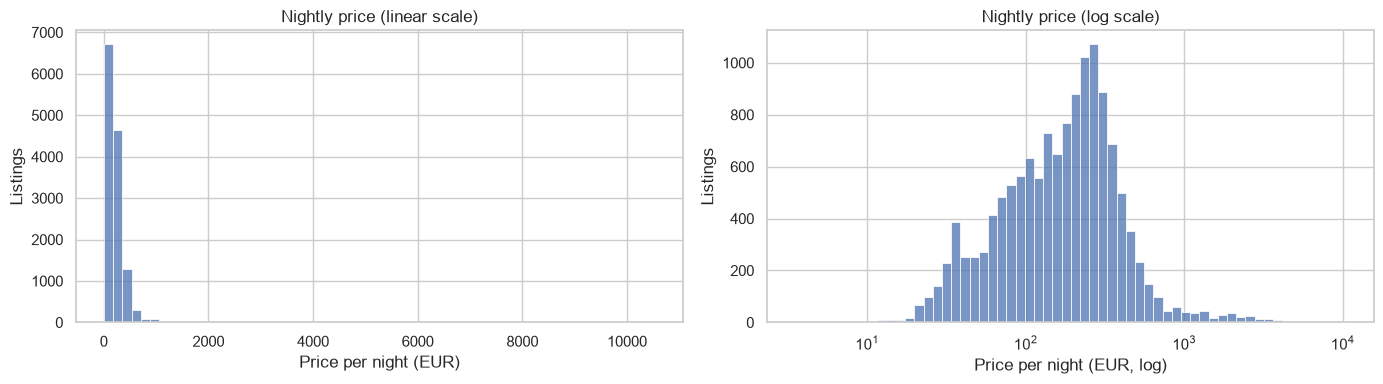

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(listings["price_eur"].dropna(), bins=60, ax=axes[0])
axes[0].set(title="Nightly price (linear scale)", xlabel="Price per night (EUR)", ylabel="Listings")

sns.histplot(listings["price_eur"].dropna(), bins=60, log_scale=True, ax=axes[1])
axes[1].set(title="Nightly price (log scale)", xlabel="Price per night (EUR, log)", ylabel="Listings")

plt.tight_layout()
plt.show()

In [19]:
q1, q3 = listings["price_eur"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr

print(f"Q1 = €{q1:.0f}, Q3 = €{q3:.0f}, upper Tukey fence = €{upper:.0f}")
print("listings above the fence:", (listings["price_eur"] > upper).sum())

listings.nlargest(5, "price_eur")[["price_eur", "room_type", "accommodates", "number_of_reviews_ltm"]]

Q1 = €89, Q3 = €286, upper Tukey fence = €580
listings above the fence: 586


,price_eur,room_type,accommodates,number_of_reviews_ltm
8077,10542.22,Entire home/apt,2,0
12321,7532.00,Entire home/apt,16,0
12139,7293.00,Entire home/apt,16,0
12155,6151.00,Entire home/apt,16,0
12112,6106.00,Entire home/apt,16,0


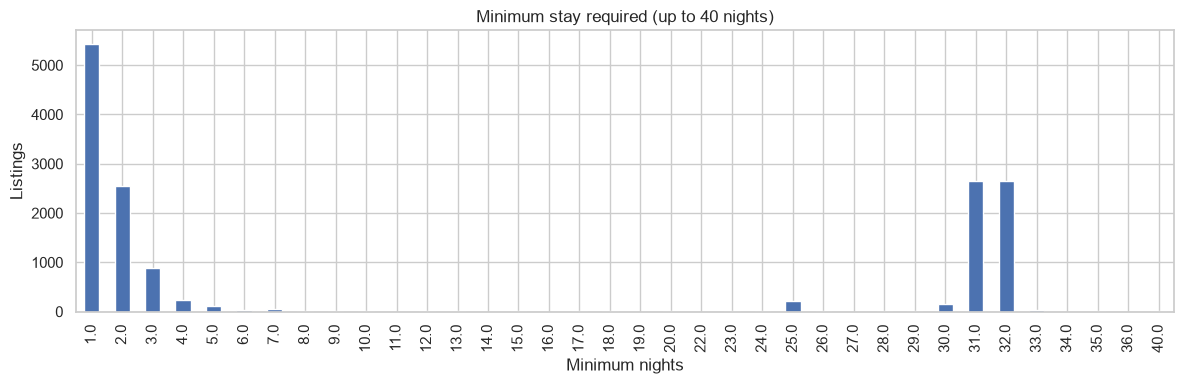

In [20]:
min_nights_counts = listings["minimum_nights"].value_counts().sort_index().loc[:40]

fig, ax = plt.subplots(figsize=(12, 4))
min_nights_counts.plot(kind="bar", ax=ax)
ax.set(title="Minimum stay required (up to 40 nights)", xlabel="Minimum nights", ylabel="Listings")
plt.tight_layout()
plt.show()

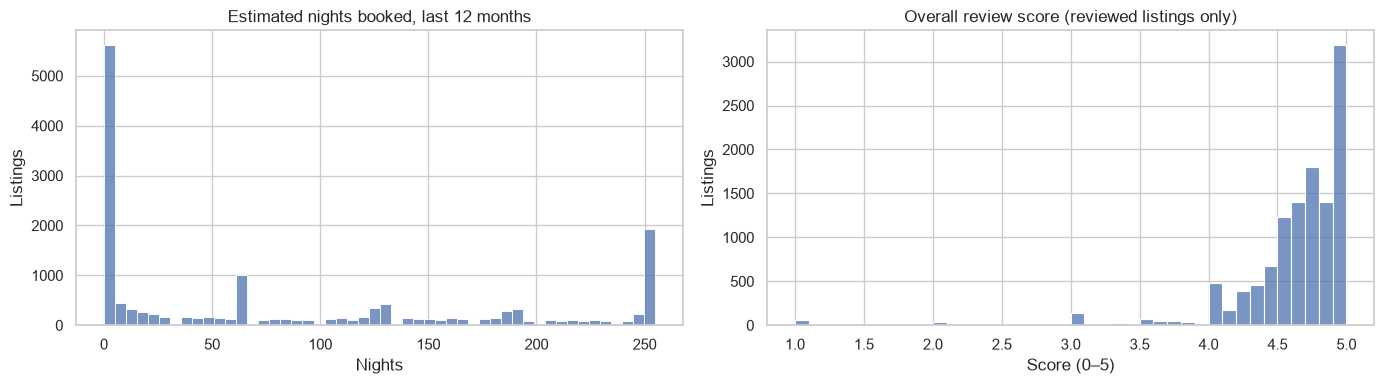

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(listings["estimated_occupancy_l365d"], bins=50, ax=axes[0])
axes[0].set(title="Estimated nights booked, last 12 months",
            xlabel="Nights", ylabel="Listings")

sns.histplot(listings["review_scores_rating"].dropna(), bins=40, ax=axes[1])
axes[1].set(title="Overall review score (reviewed listings only)",
            xlabel="Score (0–5)", ylabel="Listings")

plt.tight_layout()
plt.show()

### Decisions from the distributions

- **Price** is extremely right-skewed (skew ≈ 9, max €10,542). 586 listings sit above the IQR fence (≈ €580), and the most expensive ones had no reviews in the last year. Decision: **keep them, compare groups with the median**, not the mean.
- **Minimum nights** has two peaks: 1–2 nights and 31–32 nights. The spike at 32 suggests hosts set their minimum just above the 31-day threshold of the tourist-licence rules. This supports defining the Q2 segment as `minimum_nights >= 31`.
- **Estimated occupancy** has a large block at 0 nights: a sizeable share of listings looks inactive. This is an estimate based on reviews, to be stated as a limitation.
- **Review scores** cluster between 4.5 and 5 (skew ≈ −3.7), so they discriminate poorly between groups. They are used only as a supporting metric.

---
## 5. Categorical columns

**This is the section that feeds tomorrow.** A column with few distinct values repeated over many rows is a lookup table waiting to happen. Find them.

In [22]:
text_cols = listings.select_dtypes(exclude="number")
n_unique = text_cols.nunique().sort_values()
n_unique[n_unique <= 100]

host_identity_verified           2
host_has_profile_pic             2
has_availability                 2
host_is_superhost                2
source                           2
calendar_last_scraped            4
room_type                        4
last_scraped                     4
neighbourhood_group_cleansed    10
bathrooms_text                  37
property_type                   50
neighbourhood_cleansed          69
dtype: int64

In [23]:
for col in ["room_type", "neighbourhood_group_cleansed"]:
    print(listings[col].value_counts(), "\n")

room_type
Entire home/apt    10844
Private room        4262
Shared room          119
Hotel room            68
Name: count, dtype: int64 

neighbourhood_group_cleansed
Eixample               5835
Ciutat Vella           3247
Sants-Montjuïc         1448
Sant Martí             1436
Gràcia                 1366
Sarrià-Sant Gervasi     888
Horta-Guinardó          358
Les Corts               327
Sant Andreu             225
Nou Barris              163
Name: count, dtype: int64 



In [24]:
print(listings["property_type"].value_counts().head(8))
print("\nproperty types with fewer than 10 listings:",
      (listings["property_type"].value_counts() < 10).sum())

property_type
Entire rental unit             9772
Private room in rental unit    3021
Room in hotel                   449
Entire serviced apartment       364
Entire condo                    312
Private room in hostel          210
Entire loft                     187
Private room in home            162
Name: count, dtype: int64

property types with fewer than 10 listings: 25


In [25]:
districts_per_neighbourhood = listings.groupby("neighbourhood_cleansed")["neighbourhood_group_cleansed"].nunique()
print("max districts per neighbourhood:", districts_per_neighbourhood.max())

max districts per neighbourhood: 1


In [26]:
host_cols = ["host_name", "host_is_superhost", "host_listings_count",
             "host_identity_verified", "host_has_profile_pic", "calculated_host_listings_count"]

print("distinct hosts:", listings["host_id"].nunique())
listings.groupby("host_id")[host_cols].nunique().max()

distinct hosts: 4595


host_name                         1
host_is_superhost                 1
host_listings_count               1
host_identity_verified            1
host_has_profile_pic              1
calculated_host_listings_count    1
dtype: int64

In [27]:
lic = listings["license"]

conditions = [
    lic.isna(),
    lic.str.contains("Exempt - seasonal", na=False),
    lic.str.contains(r"HUTB-?\d", na=False),
    lic.str.contains("Exempt", na=False),
]
labels = ["missing", "exempt_seasonal", "hutb_licence", "exempt_other"]

listings["licence_status"] = np.select(conditions, labels, default="other_code")
listings["licence_status"].value_counts()

licence_status
hutb_licence       7406
missing            3043
exempt_seasonal    2960
other_code         1159
exempt_other        725
Name: count, dtype: int64

In [28]:
pd.crosstab(listings["room_type"], listings["licence_status"])

licence_status,exempt_other,exempt_seasonal,hutb_licence,missing,other_code
room_type,,,,,
Entire home/apt,85,2145,6746,1139,729
Hotel room,32,0,17,0,19
Private room,523,814,641,1895,389
Shared room,85,1,2,9,22


### Candidate tables

| Table | Grain | Key | Why it exists |
|---|---|---|---|
| `listings` | one listing | `listing_id` | Main table: the rows being analysed |
| `reviews` | one review | `review_id`, FK `listing_id` | Second record table, already related by a real key (1 listing → N reviews) |
| `hosts` | one host (4,595) | `host_id` | Host attributes are constant per host (checked in 5.4): a table with real attributes, not a label |
| `neighbourhoods` | one neighbourhood (69) | `neighbourhood_id`, FK `district_id` | Each belongs to exactly one district (checked in 5.3) |
| `districts` | one district (10) | `district_id` | Top of a two-level hierarchy used to answer Q1 |
| `licence_status` | one status (5) | `licence_status_id` | Derived from the messy `license` field; the core variable of Q1 |

### Rejected, and why

- **`room_type` (4 values):** kept as a column. A 4-row table adds a join and no information.
- **`property_type` (50 values):** half the values have fewer than 10 listings, and it mostly repeats `room_type` in more detail. Not needed for Q1/Q2.
- **Booleans and `source`:** flags, not categories. They stay as 0/1 columns.
- **Scrape dates:** dates, not categories.

---
## 6. Research questions

At least two, written here. Specific, answerable with this data, and with an answer you could be wrong about. For each one, say what you expect and why.

1. What share of Barcelona's short-stay Airbnb listings shows no verifiable tourist licence, and in which districts and room types is it concentrated?
2. How large is the mid-term (31+ nights) segment, and how does it compare with licensed short-stay listings on **price per guest**, location and activity?

**Definitions used in both questions**

- **Short-stay listing:** `minimum_nights < 31`. These are the listings Barcelona's tourist-licence rules apply to.
- **Mid-term listing:** `minimum_nights >= 31`. Declared as seasonal rentals, outside the tourist-licence regime.
- **Active listing:** at least one review in the 12 months before the snapshot (24 June 2026), computed from the `reviews` table.
- **Prices** are nightly, in EUR, compared with the **median** because the distribution is extremely skewed (section 4).

---

### Q1: Licence compliance

**Question:** What share of Barcelona's short-stay Airbnb listings shows no verifiable tourist licence, and in which districts and room types is it concentrated?

**Hypothesis:** Unlicensed short-stay supply is concentrated in **private rooms** and in **outer districts** rather than the tourist centre, and **most of it is inactive**.

**Why I expect this:** in section 5, 1,895 of the 3,043 listings without a licence were private rooms. Barcelona does not grant tourist licences for rooms, so they cannot show one. The centre is the most inspected area, so unlicensed hosts are more likely to operate further out. The block of listings with zero estimated occupancy (section 4) suggests many unlicensed listings are dormant.

**Who cares / what decision:** the city council's inspection team, deciding where to focus inspections; Airbnb's trust & safety team, deciding which listings to require a licence from. If most unlicensed listings are inactive, the real enforcement problem is much smaller than the headline count.

**How I could be wrong:** unlicensed listings may turn out to be spread evenly across districts, or to be as active as licensed ones.

---

### Q2: The mid-term rental segment

**Question:** How large is the mid-term (31+ nights) segment, and how does it compare with licensed short-stay listings on **price per guest**, location and activity?

**Hypothesis:** The mid-term segment is **concentrated in the same central districts** as licensed short-stay listings, is **cheaper per guest**, and is **less active**, suggesting it partly absorbs supply that cannot get a tourist licence rather than being a separate product.

**Why I expect this:** in section 4, `minimum_nights` spikes at 31 and 32, just above the threshold where the licence rules stop applying: hosts seem to be choosing the minimum to fit the rules. Mid-term listings are smaller (median 2 guests vs 4), so price must be compared **per guest** (`price / accommodates`), not per night, to be fair.

**Who cares / what decision:** housing policy makers, deciding whether seasonal rentals need their own regulation; property owners and investors, choosing between short-stay and mid-term rental models.

**How I could be wrong:** mid-term listings may sit in residential, non-touristic

---
## 7. Into notebook 02

The tables you are going to build, and the problems you have to fix first.

### Tables to build

    districts (10)
       │ 1
       │ N
    neighbourhoods (69)            hosts (4,595)        licence_status (5)
       │ 1                            │ 1                   │ 1
       │ N                            │ N                   │ N
       └──────────────► listings (15,293) ◄─────────────────┘
                              │ 1
                              │ 0..N
                          reviews (~1.03M)

| Table | Primary key | Foreign keys | Columns kept |
|---|---|---|---|
| `districts` | `district_id` | — | `district_name` |
| `neighbourhoods` | `neighbourhood_id` | `district_id` → districts | `neighbourhood_name` |
| `hosts` | `host_id` | — | `host_name`, `is_superhost`, `identity_verified`, `host_listings_count` |
| `licence_status` | `licence_status_id` | — | `status_code`, `description` |
| `listings` | `listing_id` | `host_id`, `neighbourhood_id`, `licence_status_id` | `room_type`, `accommodates`, `price_eur`, `minimum_nights`, `availability_365`, `number_of_reviews`, `number_of_reviews_ltm`, `estimated_occupancy_l365d`, `review_scores_rating`, `licence_number`, `source` |
| `reviews` | `review_id` | `listing_id` → listings | `review_date`, `reviewer_id` |

**Relationships**
- One district has many neighbourhoods; each neighbourhood belongs to exactly one district (checked in 5.3).
- One neighbourhood, one host and one licence status each have many listings.
- One listing has **zero or more** reviews: 3,548 listings have none, which a 1-to-many relationship allows.

**Edge cases to handle explicitly**
- **Orphan reviews:** 6,592 reviews point to listings not in the snapshot. They are removed before loading, and the count is reported.
- **Nullable columns kept on purpose:** `price_eur` (not live in this scrape), `review_scores_rating` (never reviewed), `licence_number` (no licence shown).

### Fix list for notebook 02 (in this order)

1. **Drop** the 12 fully empty columns and the columns not in the table above.
2. **Convert types:** `price` → `price_eur` (strip `$` and `,`, float, EUR); dates → `datetime`; `"t"/"f"` → 1/0.
3. **Parse `license`** into `licence_status` (5 categories, accepting `HUTB` with or without a hyphen) and `licence_number`.
4. **Handle nulls** as decided in section 3: keep `price_eur`, `review_scores_rating` and `licence_number` as null; check the single missing `minimum_nights`.
5. **Build the lookup tables** (`districts`, `neighbourhoods`, `hosts`, `licence_status`) and replace text columns in `listings` with their ids.
6. **Remove orphan reviews** and verify that every foreign key has a matching parent (0 orphans).
7. **Export** one CSV per table to `data/clean/`, then load into SQLite with the schema from `sql/schema.sql`.